In [24]:
 # ===============================
# STEP 1: IMPORT REQUIRED LIBRARIES
# We import PyTorch, datasets, and tools for training a neural network
# ==============================================================
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [27]:
# ===============================
# STEP 3: LOAD FASHION-MNIST DATASET
# This dataset contains 28x28 grayscale images of clothing items
# ===============================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [29]:
# ===============================
# STEP 4: SPLIT DATA INTO TRAIN AND VALIDATION SET
# 80% training data, 20% validation data
# ===============================
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [30]:
# ===============================
# STEP 5: CREATE DATALOADERS
# DataLoaders help load data in batches for training efficiency
# ===============================
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# ===============================
# STEP 6: BUILD NEURAL NETWORK MODEL
# This is a simple feed-forward neural network (MLP)
# It converts images into predictions (0–9 classes)
# ===============================

class FashionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [31]:
# ===============================
# STEP 7: INITIALIZE MODEL, LOSS FUNCTION, OPTIMIZER
# Loss function measures error
# Optimizer updates model weights
# ===============================
model = FashionModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# ===============================
# STEP 8: TRAINING FUNCTION
# This function trains the model on training data
# It updates weights using backpropagation
# ===============================
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [9]:
# ===============================
# STEP 9: VALIDATION FUNCTION
# This checks model performance on unseen data
# No weight updates happen here
# ===============================
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

In [10]:
# ===============================
# STEP 10: TRAINING LOOP
# Repeats training + validation for multiple epochs
# Shows improvement over time
# ===============================
epochs = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*40)

Epoch 1/10
Train Loss: 0.5170 | Train Acc: 0.8111
Val Loss: 0.4062 | Val Acc: 0.8470
----------------------------------------
Epoch 2/10
Train Loss: 0.3789 | Train Acc: 0.8613
Val Loss: 0.3585 | Val Acc: 0.8652
----------------------------------------
Epoch 3/10
Train Loss: 0.3463 | Train Acc: 0.8721
Val Loss: 0.3477 | Val Acc: 0.8710
----------------------------------------
Epoch 4/10
Train Loss: 0.3175 | Train Acc: 0.8832
Val Loss: 0.3338 | Val Acc: 0.8797
----------------------------------------
Epoch 5/10
Train Loss: 0.2942 | Train Acc: 0.8901
Val Loss: 0.3249 | Val Acc: 0.8788
----------------------------------------
Epoch 6/10
Train Loss: 0.2787 | Train Acc: 0.8965
Val Loss: 0.3269 | Val Acc: 0.8788
----------------------------------------
Epoch 7/10
Train Loss: 0.2627 | Train Acc: 0.9023
Val Loss: 0.3155 | Val Acc: 0.8856
----------------------------------------
Epoch 8/10
Train Loss: 0.2534 | Train Acc: 0.9052
Val Loss: 0.3167 | Val Acc: 0.8905
---------------------------------

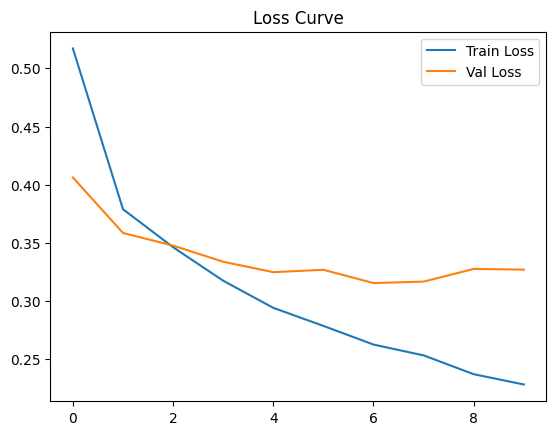

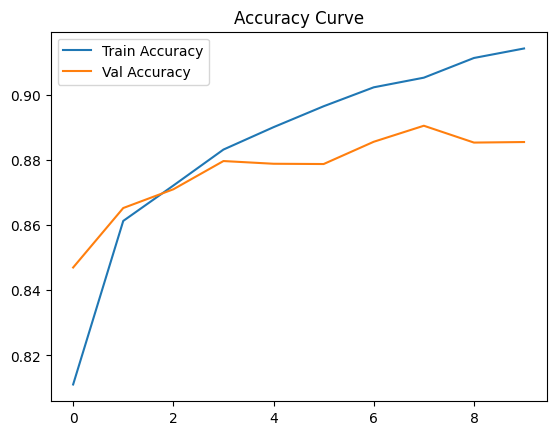

In [11]:
# ===============================
# STEP 11: VISUALIZE RESULTS
# Shows loss curve to understand model learning
# ===============================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [12]:
torch.save(model.state_dict(), "fashion_mnist_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [13]:
# ===============================
# STEP 12: SAVE TRAINED MODEL
# Saves learned weights so we can reuse model later
# ===============================
model = FashionModel().to(device)
model.load_state_dict(torch.load("fashion_mnist_model.pth"))
model.eval()

FashionModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [14]:
# ===============================
# STEP 13: MAKE PREDICTIONS ON TEST DATA
# Model predicts labels for unseen test images
# ===============================
model.eval()
predictions = []

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

In [17]:
# ===============================
# STEP 14: CREATE SUBMISSION FILE
# Stores predictions in required format (id, label)
# ===============================
submission = pd.DataFrame({
    "id": list(range(len(predictions))),
    "label": predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [22]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>